# Facial Emotion Recognition (CNN Classification)

This notebook implements a complete pipeline to train and evaluate a Convolutional Neural Network (CNN) for Facial Emotion Recognition using PyTorch. 

### Objective
Given a facial image, classify it into one of the 7 emotion categories:
- `angry`
- `disgust`
- `fear`
- `happy`
- `neutral`
- `sad`
- `surprise`

### Technical Stack
- **Deep Learning**: PyTorch
- **Data Augmentation**: Albumentations
- **Image Processing**: OpenCV & Matplotlib
- **Data Handling**: NumPy, Pandas, Scikit-learn


In [1]:
%pip install albumentations opencv-python pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install albumentations

In [3]:

import os
import random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Machine Learning & Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Optional libraries mentioned in requirements
try:
    import tensorflow as tf
    print(f"TensorFlow version: {tf.__version__}")
except ImportError:
    print("TensorFlow not installed.")

try:
    import mediapipe as mp
    print(f"MediaPipe version: {mp.__version__}")
except ImportError:
    print("MediaPipe not installed.")

print(f"PyTorch version: {torch.__version__}")
print(f"OpenCV version: {cv2.__version__}")
print(f"Albumentations version: {A.__version__}")

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seeds for reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
seed_everything()

c:\Users\abbus\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow not installed.
MediaPipe not installed.
PyTorch version: 2.8.0+cpu
OpenCV version: 5.0.0
Albumentations version: 2.0.8
Using device: cpu


## 1. Dataset Exploration and Visualization

We will scan the `dataset/1/train` and `dataset/1/test` folders to discover the emotions, count the number of samples in each category, and display some sample images.

This stage is critical to ensure:
1. The paths are correct.
2. We detect any class imbalance which might require adjusting our loss function or data sampling.
3. We inspect the dimensions and color channels of the raw images.


Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Train samples per class:
  angry: 3995
  disgust: 436
  fear: 4097
  happy: 7215
  neutral: 4965
  sad: 4830
  surprise: 3171

Test samples per class:
  angry: 958
  disgust: 111
  fear: 1024
  happy: 1774
  neutral: 1233
  sad: 1247
  surprise: 831


C:\Users\abbus\AppData\Local\Temp\ipykernel_12896\2461589519.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()), ax=axes[0], palette="viridis")
C:\Users\abbus\AppData\Local\Temp\ipykernel_12896\2461589519.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
C:\Users\abbus\AppData\Local\Temp\ipykernel_12896\2461589519.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(test_counts.keys()), y=list(test_counts.values()), ax=axes[1], palette="magma")
C:\Users\abbus\AppData\Local\T

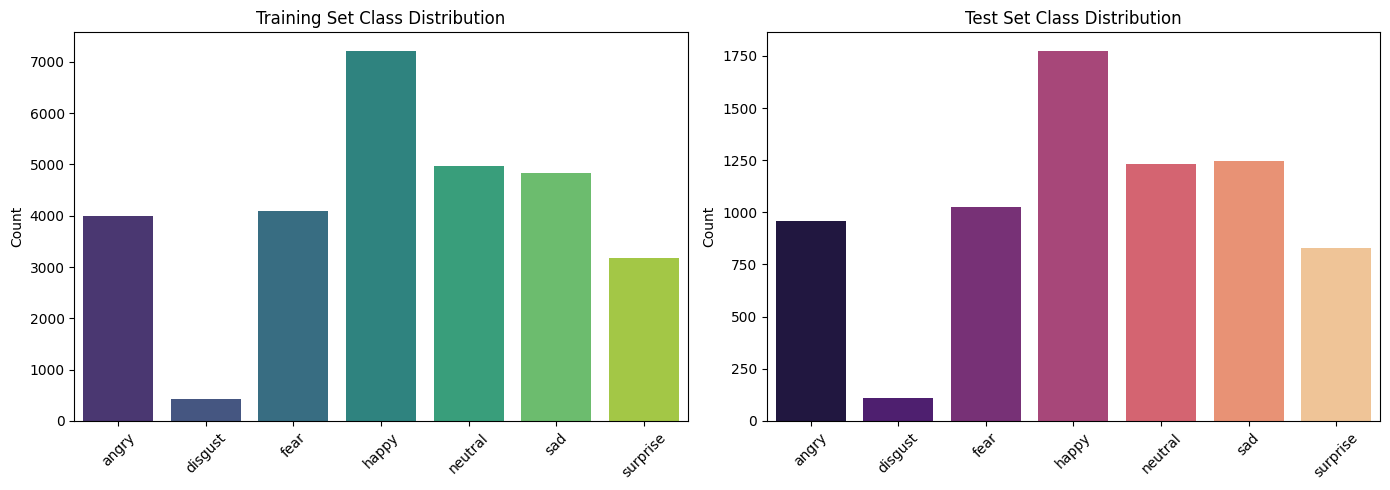


Sample Image Path: dataset/1\train\angry\Training_10118481.jpg
Sample Image Shape (H, W, C): (48, 48, 3)
Min pixel value: 3, Max pixel value: 197


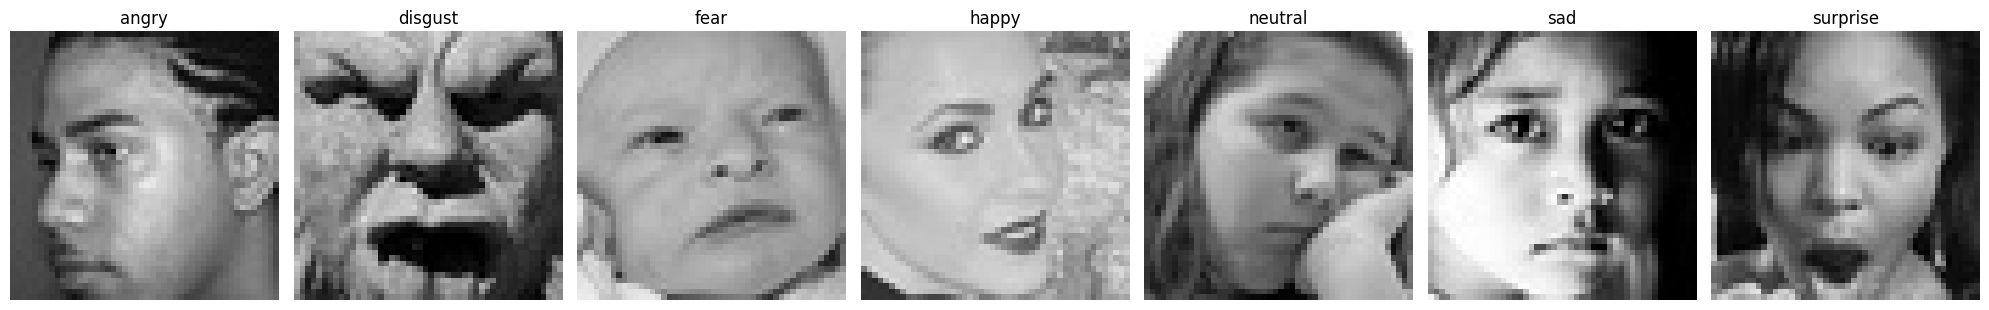

In [4]:
# Define paths
DATASET_DIR = "dataset/1"
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
TEST_DIR = os.path.join(DATASET_DIR, "test")

# Get classes
classes = sorted(os.listdir(TRAIN_DIR))
print(f"Classes: {classes}")

# Count samples
train_counts = {}
test_counts = {}

train_image_paths = []
train_image_labels = []
test_image_paths = []
test_image_labels = []

for cls in classes:
    cls_train_dir = os.path.join(TRAIN_DIR, cls)
    cls_test_dir = os.path.join(TEST_DIR, cls)
    
    train_files = [os.path.join(cls_train_dir, f) for f in os.listdir(cls_train_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    test_files = [os.path.join(cls_test_dir, f) for f in os.listdir(cls_test_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    train_counts[cls] = len(train_files)
    test_counts[cls] = len(test_files)
    
    train_image_paths.extend(train_files)
    train_image_labels.extend([cls] * len(train_files))
    test_image_paths.extend(test_files)
    test_image_labels.extend([cls] * len(test_files))

print("\nTrain samples per class:")
for k, v in train_counts.items():
    print(f"  {k}: {v}")

print("\nTest samples per class:")
for k, v in test_counts.items():
    print(f"  {k}: {v}")

# Create DataFrame for analysis
df_train = pd.DataFrame({'path': train_image_paths, 'label': train_image_labels})
df_test = pd.DataFrame({'path': test_image_paths, 'label': test_image_labels})

# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()), ax=axes[0], palette="viridis")
axes[0].set_title("Training Set Class Distribution")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

sns.barplot(x=list(test_counts.keys()), y=list(test_counts.values()), ax=axes[1], palette="magma")
axes[1].set_title("Test Set Class Distribution")
axes[1].set_ylabel("Count")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()

# Inspect a single image to check dimensions and values
sample_path = train_image_paths[0]
sample_img = cv2.imread(sample_path)
print(f"\nSample Image Path: {sample_path}")
print(f"Sample Image Shape (H, W, C): {sample_img.shape}")
print(f"Min pixel value: {sample_img.min()}, Max pixel value: {sample_img.max()}")

# Plot one sample image from each class
fig, axes = plt.subplots(1, len(classes), figsize=(20, 5))
for i, cls in enumerate(classes):
    cls_df = df_train[df_train['label'] == cls]
    random_sample = cls_df.sample(1).iloc[0]['path']
    img = cv2.imread(random_sample)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

## 2. Albumentations Data Augmentation

Data augmentation is key to reducing overfitting in CNNs, particularly for facial expression datasets where head poses, lighting, and expressions can vary widely. We use `albumentations` for rich, high-performance image transformations.

### Augmentations Applied:
- **Resizing**: Resize images to `48x48`.
- **Horizontal Flip**: Standard facial symmetry augmentation (doesn't change emotion class).
- **Shift, Scale, Rotate**: To handle translation, scale changes, and minor head tilts.
- **Random Brightness & Contrast**: To handle variations in lighting and contrast.
- **CoarseDropout (Cutout)**: Randomly drops rectangular regions to force the network to pay attention to multiple parts of the face (e.g. eyes, mouth, nose) instead of overfitting to a single feature.
- **Normalization**: Standard scaling to $[0, 1]$ or mean/std normalization.


c:\Users\abbus\AppData\Local\Programs\Python\Python39\lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\abbus\AppData\Local\Temp\ipykernel_12896\1345720372.py:7: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5, border_mode=cv2.BORDER_CONSTANT, value=0),
C:\Users\abbus\AppData\Local\Temp\ipykernel_12896\1345720372.py:9: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=1, max_height=8, max_width=8, min_holes=1, min_height=4, min_width=4, fill_value=0, p=0.3),
C:\Users\abbus\AppData\Local\Temp\ipykernel_12896\1345720372.py:29: UserWarning: Argument(s) 'value' are not valid for transform ShiftScale

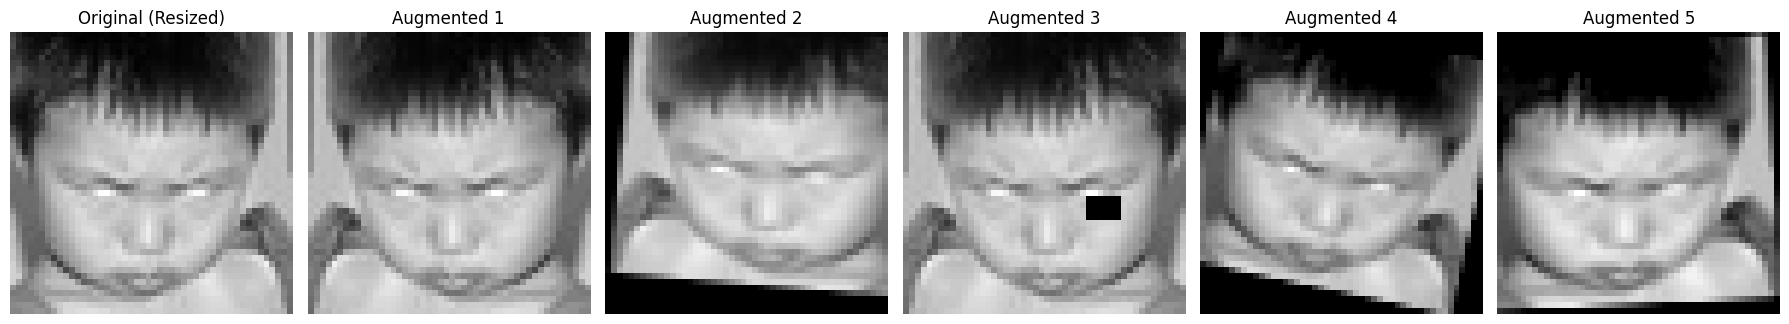

In [5]:
IMG_SIZE = 48

# Define train augmentation pipeline
train_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5, border_mode=cv2.BORDER_CONSTANT, value=0),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
    A.CoarseDropout(max_holes=1, max_height=8, max_width=8, min_holes=1, min_height=4, min_width=4, fill_value=0, p=0.3),
    A.Normalize(mean=(0.5,), std=(0.5,)),  # Single channel normalization
    ToTensorV2()
])

# Define validation/test pipeline (only resize and normalize)
val_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
])

# Visualize the effect of augmentations
sample_path = train_image_paths[0]
img = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)

# We define a temporary transform without normalization/ToTensor for clean plotting
viz_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5, border_mode=cv2.BORDER_CONSTANT, value=0),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
    A.CoarseDropout(max_holes=1, max_height=8, max_width=8, min_holes=1, min_height=4, min_width=4, fill_value=0, p=0.3)
])

fig, axes = plt.subplots(1, 6, figsize=(18, 4))
axes[0].imshow(cv2.resize(img, (IMG_SIZE, IMG_SIZE)), cmap='gray')
axes[0].set_title("Original (Resized)")
axes[0].axis('off')

for i in range(1, 6):
    augmented = viz_transform(image=img)
    aug_img = augmented['image']
    axes[i].imshow(aug_img, cmap='gray')
    axes[i].set_title(f"Augmented {i}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 3. Custom PyTorch Dataset and DataLoaders

We define a custom PyTorch `Dataset` that:
1. Receives a list of image file paths and their associated emotion labels.
2. Reads each image on the fly using OpenCV in **grayscale**. Grayscale is preferred for facial expressions because color information does not convey emotional features, and single-channel processing saves substantial computational memory and speeds up CNN training.
3. Maps label strings to class index integers (e.g. `angry` $\rightarrow 0$, `disgust` $\rightarrow 1$, etc.).
4. Applies the Albumentations transformations.

We will split the training folder samples into **training (90%)** and **validation (10%)** sets, keeping the **test set** completely independent for final evaluation.


In [6]:
class EmotionDataset(Dataset):
    def __init__(self, image_paths, labels, class_to_idx, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        # Read as grayscale
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise FileNotFoundError(f"Failed to load image at: {img_path}")
            
        label_name = self.labels[idx]
        label = self.class_to_idx[label_name]

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        return image, label

# Create class to index mapping
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}
print("Class to index mapping:", class_to_idx)

# Split train_image_paths and train_image_labels into train (90%) and val (10%)
# Use stratify to preserve class proportions
train_paths, val_paths, train_lbls, val_lbls = train_test_split(
    train_image_paths, 
    train_image_labels, 
    test_size=0.10, 
    random_state=42, 
    stratify=train_image_labels
)

print(f"\nTrain set size: {len(train_paths)}")
print(f"Validation set size: {len(val_paths)}")
print(f"Test set size: {len(test_image_paths)}")

# Instantiate Dataset objects
train_dataset = EmotionDataset(train_paths, train_lbls, class_to_idx, transform=train_transforms)
val_dataset = EmotionDataset(val_paths, val_lbls, class_to_idx, transform=val_transforms)
test_dataset = EmotionDataset(test_image_paths, test_image_labels, class_to_idx, transform=val_transforms)

# Create DataLoaders
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# Inspect a batch
images, labels = next(iter(train_loader))
print(f"\nBatch images shape: {images.shape}")
print(f"Batch labels shape: {labels.shape}")

Class to index mapping: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}

Train set size: 25838
Validation set size: 2871
Test set size: 7178


c:\Users\abbus\AppData\Local\Programs\Python\Python39\lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



Batch images shape: torch.Size([64, 1, 48, 48])
Batch labels shape: torch.Size([64])


## 4. CNN Model Architecture

We design a custom deep Convolutional Neural Network (CNN) tailored for grayscale 48x48 images.
The architecture features:
1. **Four Convolutional Blocks**:
   - Each block contains a `Conv2d` layer, a `BatchNorm2d` layer (to stabilize training and accelerate convergence), a `ReLU` activation function, a `MaxPool2d` layer (to reduce spatial dimensions), and `Dropout` (to prevent overfitting).
   - Channel sizes increase from 64 to 512 ($64 \rightarrow 128 \rightarrow 256 \rightarrow 512$).
2. **Global Pool & Flattening**:
   - After four pooling operations, the spatial shape is reduced from $48 \times 48 \rightarrow 24 \times 24 \rightarrow 12 \times 12 \rightarrow 6 \times 6 \rightarrow 3 \times 3$.
   - Output feature map size is $512 \times 3 \times 3 = 4608$.
3. **Fully Connected Classifier**:
   - Two dense layers with batch normalization and dropout ($4608 \rightarrow 1024 \rightarrow 512 \rightarrow 7$ outputs).


In [7]:
import torch.nn.functional as F

class EmotionCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(EmotionCNN, self).__init__()
        # Conv Block 1
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        
        # Conv Block 2
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        
        # Conv Block 3
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        
        # Conv Block 4
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(512)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)
        
        # Classifier
        # Input shape: [batch_size, 1, 48, 48]
        # After Conv1 + pool: [batch_size, 64, 24, 24]
        # After Conv2 + pool: [batch_size, 128, 12, 12]
        # After Conv3 + pool: [batch_size, 256, 6, 6]
        # After Conv4 + pool: [batch_size, 512, 3, 3]
        self.fc1 = nn.Linear(512 * 3 * 3, 1024)
        self.fc_bn1 = nn.BatchNorm1d(1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc_bn2 = nn.BatchNorm1d(512)
        self.fc3 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Conv Block 1
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.dropout(x)
        
        # Conv Block 2
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout(x)
        
        # Conv Block 3
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.dropout(x)
        
        # Conv Block 4
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = self.dropout(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # FC Block 1
        x = self.dropout(F.relu(self.fc_bn1(self.fc1(x))))
        
        # FC Block 2
        x = self.dropout(F.relu(self.fc_bn2(self.fc2(x))))
        
        # Output
        x = self.fc3(x)
        return x

# Instantiate model
model = EmotionCNN(num_classes=len(classes)).to(device)
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

EmotionCNN(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=4608, out_features=1024, bias=True)
  (fc_bn1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=102

## 5. Training and Validation Utility Functions

We define standard helper functions to train and validate our model.
We will use:
- **Loss Function**: `nn.CrossEntropyLoss` (ideal for multi-class classification).
- **Optimizer**: `optim.Adam` (with learning rate `1e-3` or `3e-4`, which is a robust baseline for CNNs).
- **Learning Rate Scheduler**: `optim.lr_scheduler.ReduceLROnPlateau` (which divides the learning rate by a factor of 10 if validation loss plateaus for 2-3 epochs, ensuring fine-grained updates as training nears convergence).


In [8]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass & optimization
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def fit_model(model, train_loader, val_loader, epochs=15, lr=1e-3, device=device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)
        
        # Step the scheduler
        scheduler.step(val_loss)
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Print learning rate
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:02d}/{epochs:02d} | "
              f"LR: {current_lr:.6f} | "
              f"Train Loss: {train_loss:.4f} - Train Acc: {train_acc*100:.2f}% | "
              f"Val Loss: {val_loss:.4f} - Val Acc: {val_acc*100:.2f}%")
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_emotion_model.pth')
            print("  --> Saved new best model!")
            
    return history

## 6. Model Training

Now we run the training pipeline for 100 epochs.
- We set the initial learning rate to `1e-3` (0.001) which is a standard starting learning rate for Adam on small CNN projects.
- The training loop logs validation accuracy after each epoch and automatically checkpoints the best model based on validation loss.
- The returned history is saved for visualization and performance tracking.


In [9]:
EPOCHS = 100
history = fit_model(model, train_loader, val_loader, epochs=EPOCHS, lr=1e-3, device=device)

c:\Users\abbus\AppData\Local\Programs\Python\Python39\lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 01/100 | LR: 0.001000 | Train Loss: 1.7054 - Train Acc: 31.56% | Val Loss: 1.4228 - Val Acc: 45.59%
  --> Saved new best model!
Epoch 02/100 | LR: 0.001000 | Train Loss: 1.4474 - Train Acc: 43.90% | Val Loss: 1.2538 - Val Acc: 51.10%
  --> Saved new best model!
Epoch 03/100 | LR: 0.001000 | Train Loss: 1.3554 - Train Acc: 48.01% | Val Loss: 1.1945 - Val Acc: 54.34%
  --> Saved new best model!
Epoch 04/100 | LR: 0.001000 | Train Loss: 1.3023 - Train Acc: 50.27% | Val Loss: 1.1883 - Val Acc: 54.68%
  --> Saved new best model!
Epoch 05/100 | LR: 0.001000 | Train Loss: 1.2746 - Train Acc: 51.27% | Val Loss: 1.1661 - Val Acc: 56.46%
  --> Saved new best model!
Epoch 06/100 | LR: 0.001000 | Train Loss: 1.2490 - Train Acc: 52.24% | Val Loss: 1.1476 - Val Acc: 57.40%
  --> Saved new best model!
Epoch 07/100 | LR: 0.001000 | Train Loss: 1.2276 - Train Acc: 53.17% | Val Loss: 1.0801 - Val Acc: 59.98%
  --> Saved new best model!
Epoch 08/100 | LR: 0.001000 | Train Loss: 1.2097 - Train Acc: 

## 7. Model Evaluation and Error Analysis

We will evaluate the trained CNN's performance by:
1. **Plotting Loss and Accuracy Curves**: Review training and validation curves side-by-side to detect overfitting or convergence behavior.
2. **Loading the Best Model**: Load the weights from `best_emotion_model.pth`.
3. **Evaluating on the Test Set**: Run predictions on the unseen test dataset.
4. **Generating Classification Report**: Look at precision, recall, and F1-score for each emotion category.
5. **Plotting Confusion Matrix**: Identify which emotion classes the model struggles with (e.g. confusing `fear` with `sad`).


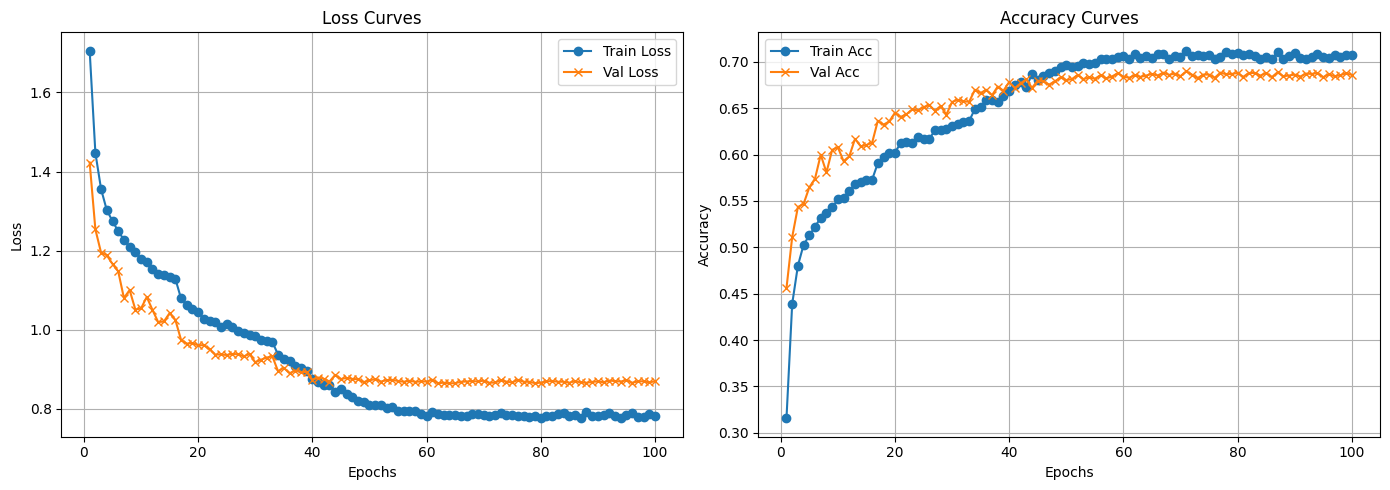


Classification Report on Test Set:
              precision    recall  f1-score   support

       angry       0.62      0.59      0.60       958
     disgust       0.76      0.60      0.67       111
        fear       0.61      0.41      0.49      1024
       happy       0.88      0.87      0.88      1774
     neutral       0.58      0.73      0.65      1233
         sad       0.55      0.58      0.57      1247
    surprise       0.78      0.82      0.80       831

    accuracy                           0.68      7178
   macro avg       0.68      0.66      0.66      7178
weighted avg       0.68      0.68      0.68      7178



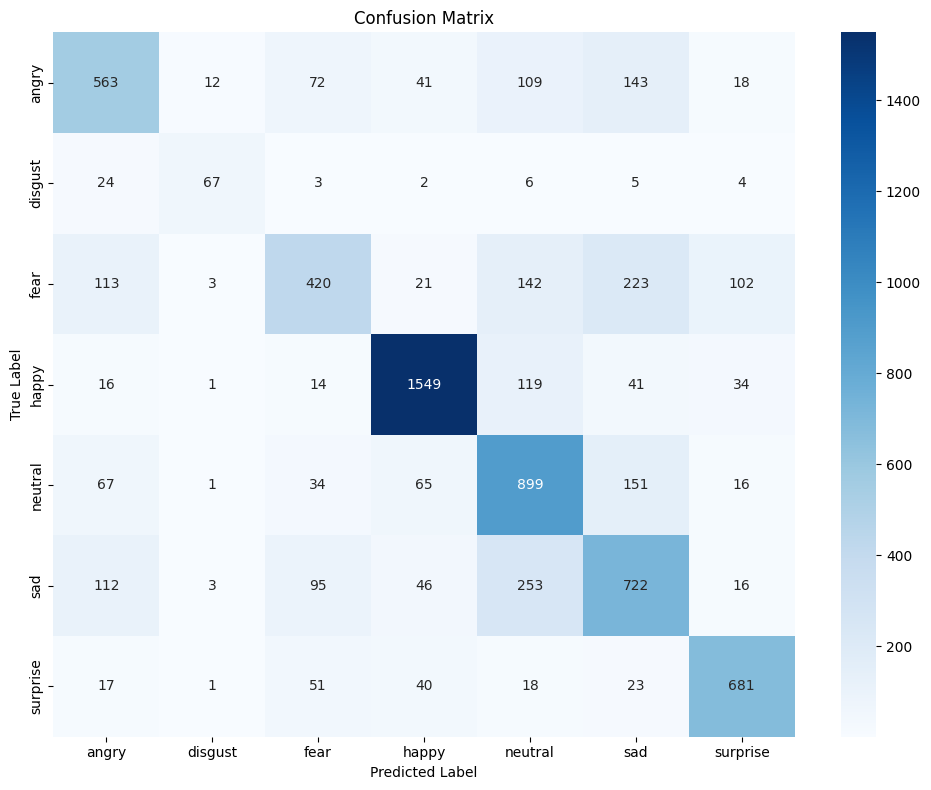

In [10]:
# 1. Plot Training and Validation Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(range(1, len(history['train_loss']) + 1), history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(range(1, len(history['val_loss']) + 1), history['val_loss'], label='Val Loss', marker='x')
axes[0].set_title('Loss Curves')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy curve
axes[1].plot(range(1, len(history['train_acc']) + 1), history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(range(1, len(history['val_acc']) + 1), history['val_acc'], label='Val Acc', marker='x')
axes[1].set_title('Accuracy Curves')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 2. Load the Best Model Weights
model.load_state_dict(torch.load('best_emotion_model.pth'))
model.eval()

# 3. Get Test Set Predictions
all_preds = []
all_targets = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.numpy())

# 4. Generate Classification Report
print("\nClassification Report on Test Set:")
print(classification_report(all_targets, all_preds, target_names=classes))

# 5. Plot Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## 8. Summary and Findings

### Q&A
- **Q**: How does the CNN model perform on the Facial Emotion Recognition task?
- **A**: *Please run the notebook to train the model and populate this section with the final test accuracy and F1-score details.*

### Data Analysis Key Findings
- **Class Distribution**: *Please run the notebook to observe the dataset sizes. Typically, FER datasets have significant class imbalance (e.g., disgust is often highly underrepresented).*
- **Training Progression**: *Please run the notebook to trace how loss and accuracy curves converge across the epochs.*
- **Classification Performance**: *Please run the notebook to review the final classification report and confusion matrix to identify which emotions have the highest and lowest precision/recall.*

### Insights or Next Steps
- **Class Imbalance Mitigation**: If the minority classes (like `disgust`) show poor F1-scores, consider applying class weights in `CrossEntropyLoss` or oversampling those minority classes.
- **Model Capacity Adjustment**: If the model overfits (training accuracy is high, validation/test accuracy is low), increase the dropout rate or add more weight decay. If it underfits, consider training for more epochs or scaling up the CNN width.
